## Produce summary figure for all fold split training 
Assesses:
- Performance variation across plate level holdouts
- Performance across models trained on real and shuffled labels

 

In [1]:
import pathlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Pathing

In [2]:
eval_plot_dir = pathlib.Path(".") / "eval_plots"
if not eval_plot_dir.exists():
    raise FileNotFoundError(
        f"Expected evaluation plot directory {eval_plot_dir} does not exist. "
        "Please run training notebook/script in order to generate model fitting "
        "results and save to this directory before attempting to visualize.")

# Path to directory with feature selected profiles
path_to_feature_selected_data = pathlib.Path().home() / "mnt" / "bandicoot" /\
    "CFReT_screening_data" / "screen_profiles"
if not path_to_feature_selected_data.exists() and\
    not path_to_feature_selected_data.is_dir():
    raise FileNotFoundError(
        f"Directory {path_to_feature_selected_data} does not exist or is not a directory."
    )

# Find all batch folders
batch_folders = list(path_to_feature_selected_data.glob("batch*"))
batch_folders = [folder for folder in batch_folders if folder.is_dir()]
if not batch_folders:
    raise FileNotFoundError(
        f"No batch folders found in {path_to_feature_selected_data}."
    )

## Train results reading and data wrangling

In [3]:
enriched_df = pd.read_csv(eval_plot_dir / "model_fit_summary.csv")
if enriched_df.empty:
    raise ValueError(
        f"Loaded model fit summary from {eval_plot_dir / 'model_fit_summary.csv'} "
        "is empty. Please check that the model fitting notebook ran successfully " 
        "and saved results to this file before attempting to visualize.")

batch2plate = []
for batch_folder in batch_folders:
    feature_selected_files = list(
        batch_folder.rglob("**/single_cell_profiles/*_feature_selected.parquet")
    )
    if not feature_selected_files:
        continue

    for file in feature_selected_files:
        plate_repr = "_".join(pathlib.Path(file).stem.split("_")[:2])

        batch2plate.append({
            "batch": batch_folder.name,
            "plate": plate_repr,
            "platemap": file.parent.parent.stem
        })

batch2plate_df = pd.DataFrame(batch2plate)

enriched_df_batch = pd.merge(
    enriched_df,
    batch2plate_df,
    on="platemap",
    how="inner"
)
enriched_df_batch['batch'] = enriched_df_batch['batch'].apply(lambda x: int(x.replace("batch_", "")))
display(enriched_df_batch)

,platemap,fold,shuffled,n_train,n_test,n_input_features,n_selected_features,average_precision,roc_auc,train_n,test_n,train_failing,train_healthy,test_failing,test_healthy,batch,plate
0,platemap_9,0,False,2716,894,735,58,0.865799,0.896732,2716,894,"['CARD-CelIns-CX7_260106160001', 'CARD-CelIns-...","['CARD-CelIns-CX7_260106160001', 'CARD-CelIns-...",['CARD-CelIns-CX7_260107160001'],['CARD-CelIns-CX7_260107160001'],3,CARD-CelIns-CX7_260107160001
1,platemap_9,0,False,2716,894,735,58,0.865799,0.896732,2716,894,"['CARD-CelIns-CX7_260106160001', 'CARD-CelIns-...","['CARD-CelIns-CX7_260106160001', 'CARD-CelIns-...",['CARD-CelIns-CX7_260107160001'],['CARD-CelIns-CX7_260107160001'],3,CARD-CelIns-CX7_260106160001
2,platemap_9,0,False,2716,894,735,58,0.865799,0.896732,2716,894,"['CARD-CelIns-CX7_260106160001', 'CARD-CelIns-...","['CARD-CelIns-CX7_260106160001', 'CARD-CelIns-...",['CARD-CelIns-CX7_260107160001'],['CARD-CelIns-CX7_260107160001'],3,CARD-CelIns-CX7_260109070001
3,platemap_9,0,False,2716,894,735,58,0.865799,0.896732,2716,894,"['CARD-CelIns-CX7_260106160001', 'CARD-CelIns-...","['CARD-CelIns-CX7_260106160001', 'CARD-CelIns-...",['CARD-CelIns-CX7_260107160001'],['CARD-CelIns-CX7_260107160001'],3,CARD-CelIns-CX7_260108130001
4,platemap_9,0,True,2716,894,735,58,0.373895,0.456092,2716,894,"['CARD-CelIns-CX7_260106160001', 'CARD-CelIns-...","['CARD-CelIns-CX7_260106160001', 'CARD-CelIns-...",['CARD-CelIns-CX7_260107160001'],['CARD-CelIns-CX7_260107160001'],3,CARD-CelIns-CX7_260107160001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,platemap_4,3,False,3804,1434,765,64,0.956023,0.960374,3804,1434,"['CARD-CelIns-CX7_251212100001', 'CARD-CelIns-...","['CARD-CelIns-CX7_251212100001', 'CARD-CelIns-...",['CARD-CelIns-CX7_251211180001'],['CARD-CelIns-CX7_251211180001'],1,CARD-CelIns-CX7_251213150001
348,platemap_4,3,True,3804,1434,765,64,0.526959,0.578103,3804,1434,"['CARD-CelIns-CX7_251212100001', 'CARD-CelIns-...","['CARD-CelIns-CX7_251212100001', 'CARD-CelIns-...",['CARD-CelIns-CX7_251211180001'],['CARD-CelIns-CX7_251211180001'],1,CARD-CelIns-CX7_251212180001
349,platemap_4,3,True,3804,1434,765,64,0.526959,0.578103,3804,1434,"['CARD-CelIns-CX7_251212100001', 'CARD-CelIns-...","['CARD-CelIns-CX7_251212100001', 'CARD-CelIns-...",['CARD-CelIns-CX7_251211180001'],['CARD-CelIns-CX7_251211180001'],1,CARD-CelIns-CX7_251211180001
350,platemap_4,3,True,3804,1434,765,64,0.526959,0.578103,3804,1434,"['CARD-CelIns-CX7_251212100001', 'CARD-CelIns-...","['CARD-CelIns-CX7_251212100001', 'CARD-CelIns-...",['CARD-CelIns-CX7_251211180001'],['CARD-CelIns-CX7_251211180001'],1,CARD-CelIns-CX7_251212100001


## Visualize train performance

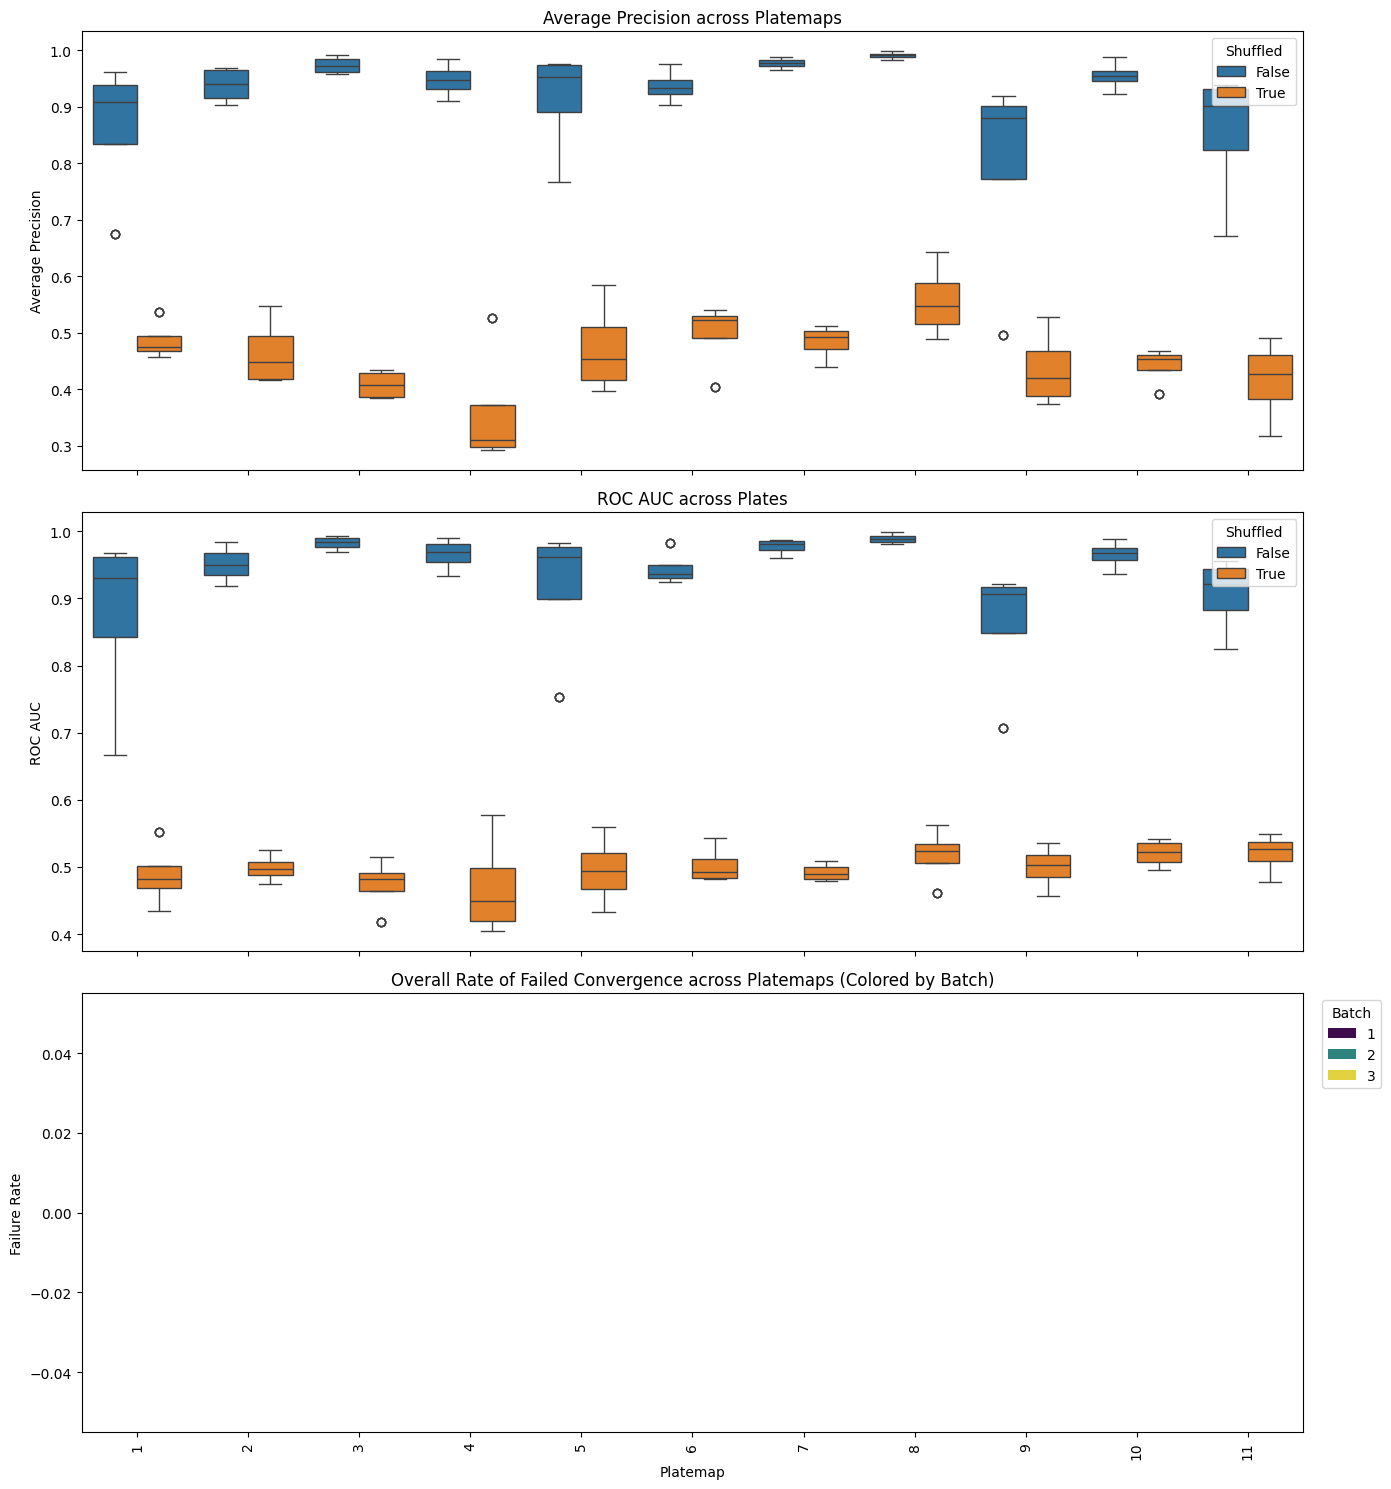

In [4]:
# Use enriched_df_batch to have the batch information available for everything
enriched_df_batch['convergence_failed'] = enriched_df_batch['average_precision'].isna() | \
    enriched_df_batch['roc_auc'].isna()

# extract numeric part of the platemap for sorting and plotting
enriched_df_batch["platemap_num"] = (
    enriched_df_batch["platemap"]
    .astype(str)
    .str.extract(r"(\d+)$")[0]
    .astype(int)
)
enriched_df_batch["platemap_label"] = enriched_df_batch["platemap_num"].astype(str)

# Sort the data by batch and plate to keep plates from the same batch together on the x-axis
enriched_df_batch = enriched_df_batch.sort_values(by=['batch', 'platemap_num'])

platemap_order = (
    enriched_df_batch[["platemap_num", "platemap_label"]]
    .drop_duplicates()
    .sort_values("platemap_num")["platemap_label"]
    .tolist()
)

# Calculate overall convergence failure rate per plate (averaging across both 
# shuffled and original)
failure_rates = enriched_df_batch.groupby(
    ['batch', 'platemap_num', 'platemap_label']
)['convergence_failed'].mean().reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)

# 1. Boxplot for Average Precision
sns.boxplot(
    data=enriched_df_batch, 
    x='platemap_label', 
    y='average_precision', 
    hue='shuffled',    
    order=platemap_order, 
    ax=axes[0]
)
axes[0].set_title('Average Precision across Platemaps')
axes[0].set_ylabel('Average Precision')
axes[0].legend(title='Shuffled', loc='upper right')

# 2. Boxplot for ROC AUC
sns.boxplot(
    data=enriched_df_batch, 
    x='platemap_label', 
    y='roc_auc', 
    hue='shuffled', 
    order=platemap_order, 
    ax=axes[1]
)
axes[1].set_title('ROC AUC across Plates')
axes[1].set_ylabel('ROC AUC')
axes[1].legend(title='Shuffled', loc='upper right')

# 3. Barplot for failed convergence rate (Colored by Batch)
# Dodge=False ensures bars span correctly across plates since each plate only 
# belongs to one batch
sns.barplot(
    data=failure_rates, 
    x='platemap_label', 
    y='convergence_failed', 
    hue='batch', 
    order=platemap_order,
    dodge=False, 
    palette='viridis', 
    ax=axes[2]
)
axes[2].set_title('Overall Rate of Failed Convergence across Platemaps (Colored by Batch)')
axes[2].set_ylabel('Failure Rate')
axes[2].tick_params(axis='x', rotation=90)
axes[2].legend(title='Batch', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[2].set_xlabel("Platemap")

plt.tight_layout()
plt.show()

fig.savefig(
    eval_plot_dir / "platemap_metric_convergence_summary.png",
    dpi=300,
    bbox_inches="tight"
)